# 06 · Databricks App — Genie + Lakebase + Knowledge Assistant + Forecast

**Pre-Hackathon Enablement · Notebook 6 of 6**

The finale: assemble everything into one **Databricks App** — a Streamlit app with
four tabs that

1. answers **data** questions with the **Genie** space from Notebook 2,
2. answers **policy / how-to** questions with the **Agent Bricks Knowledge
   Assistant** from Notebook 3,
3. charts the **demand forecast** from Notebook 4 (read from Lakebase) and runs
   **live what-if inference** against its Model Serving endpoint (Notebook 4, Step 6), and
4. logs every Genie turn — and runs a review queue — in **Lakebase** (Notebook 5).

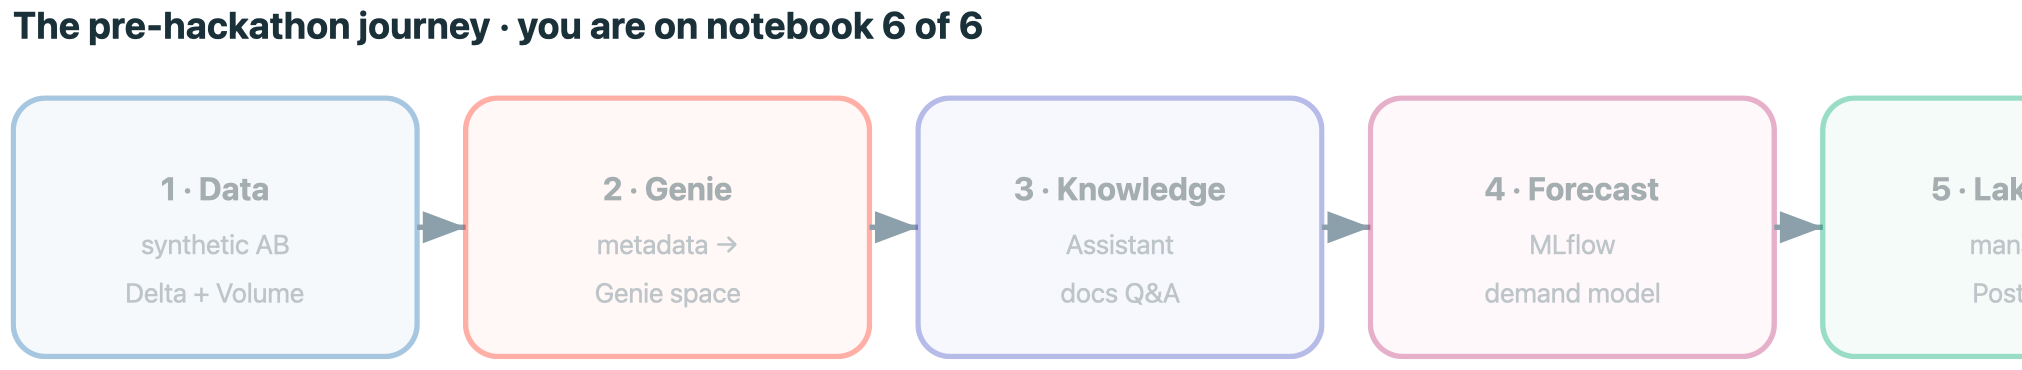

### App anatomy (from the deck)
- **Connected components:** a Databricks App can call a SQL Warehouse, Model
  Serving, **Agent Bricks**, **Genie**, and the Jobs API. Ours uses **Genie**, a
  **Knowledge Assistant** serving endpoint, and **Lakebase**.
- **Runs as a service principal (SP):** the app calls Genie, the Knowledge
  Assistant, the forecast endpoint, and Lakebase all as its **own service
  principal** — no on-behalf-of-user token exchange. That keeps it deployable on
  locked-down workspaces, and means governance is SP-level: the SP is granted access
  to everything the app touches (Step 5).
- Config lives in **`app.yaml`**; resources (Lakebase DB, Genie space, serving
  endpoint) are attached at create time and injected as env vars / grants.

### Architecture

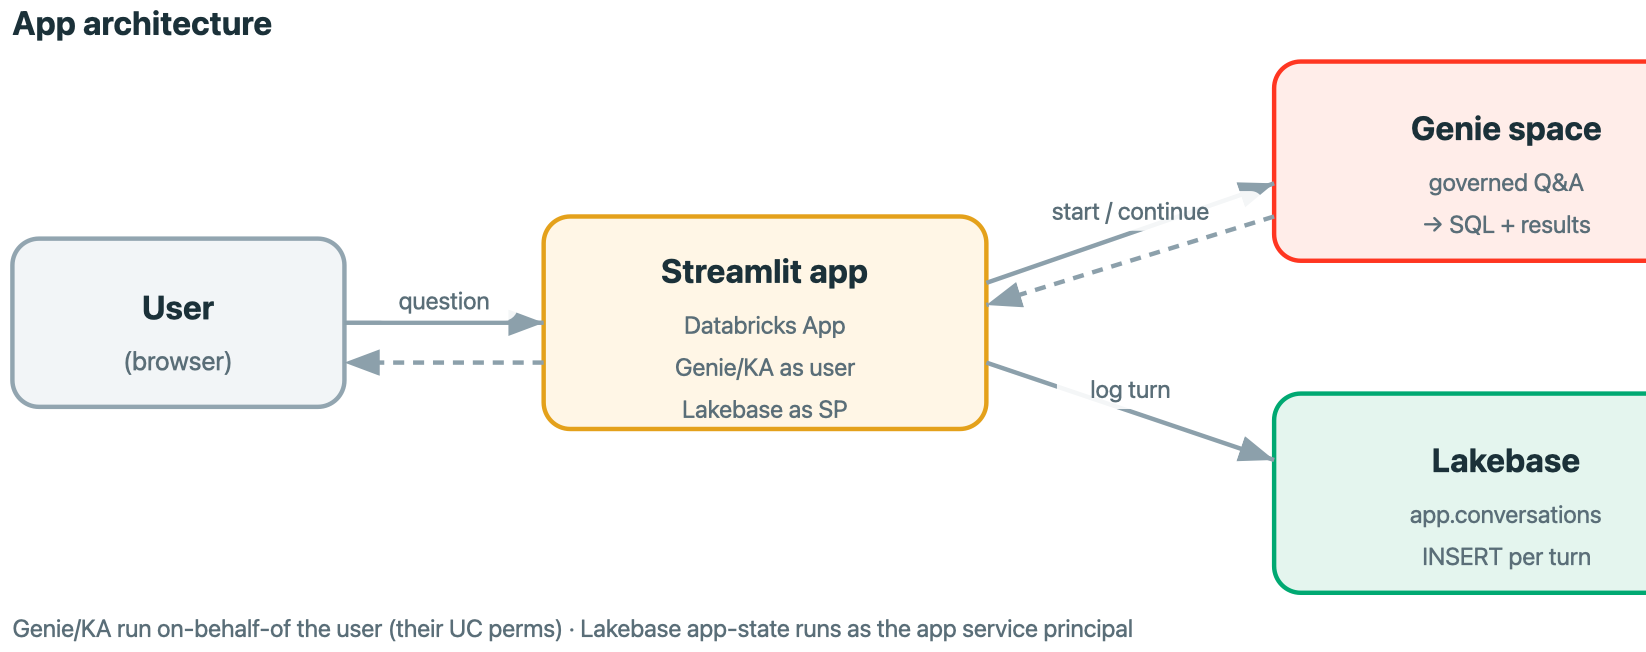

The app talks to governed services: the Genie space and the Knowledge Assistant
answer questions, and Lakebase durably records each turn (and serves the forecast
the app charts).

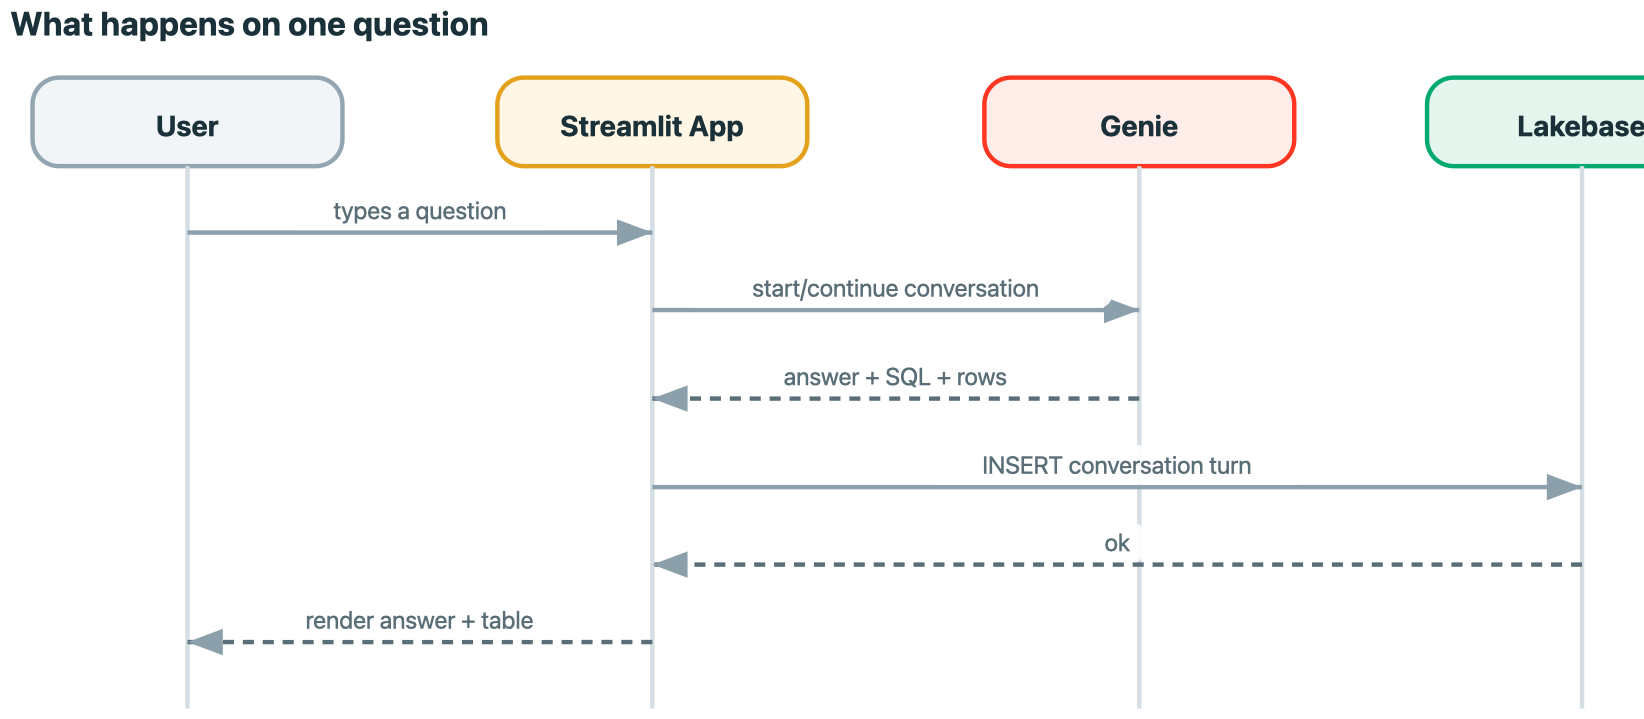

### Who the app runs as (service principal)

Every call uses **one identity: the app's service principal (SP)**. Databricks
auto-authenticates `WorkspaceClient()` inside the app as that SP, so Genie, the
Knowledge Assistant, the forecast endpoint, and Lakebase are all called as the SP —
there's no on-behalf-of-user (OBO) token exchange to configure. That's what makes
this deployable on **locked-down workspaces**, where an admin often *can't* enable
app user-authorization or allowlist the OBO `genie`/`sql`/`serving` scopes (OBO
would otherwise fail at runtime with `403 … Invalid scope, required scopes: genie`).

The trade-off: governance is **SP-level, not per-user** — everyone using the app
sees what the SP is allowed to see. That's fine for a workshop; for production
per-user governance you'd layer OBO back on. Because it all runs as the SP, **Step 5
grants that SP everything the app touches**: `CAN_RUN` on the Genie space, `CAN_USE`
on its warehouse, `CAN_QUERY` on the KA + forecast endpoints, `SELECT` on the UC
tables, and Postgres privileges on the Lakebase `app.*` tables.

> **Prerequisites:** Notebooks 1–5 done (data, Genie, Knowledge Assistant,
> forecast, Lakebase). The app source lives in the sibling **`../app/`** folder
> (`app.py`, `app.yaml`, …). This notebook **creates and deploys the app for you
> with the SDK** — no CLI needed — as long as the repo is cloned as a **Databricks
> Git folder** so `../app` is a workspace path.

## Step 0 · Setup & parameters

**Enter your resource IDs once, here** — the Genie space (Notebook 2), the
Knowledge Assistant endpoint (Notebook 3), the forecast endpoint (Notebook 4), and
your Lakebase DB — so every step below (and the deploy) uses them. Run the install
cell, then the widget cell, **set the values in the widget bar**, then run the
"read parameters" cell.

In [ ]:
%pip install --quiet --upgrade databricks-sdk psycopg2-binary sqlalchemy pyyaml
dbutils.library.restartPython()

In [ ]:
# Create the widgets. Run this cell, set the values in the widget bar up top, then
# run the next cell. (Leave forecast_endpoint blank to auto-derive the per-user name.)
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog (matches NB1)")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (username appended — matches NB1)")
dbutils.widgets.text("genie_space_id", "", "Genie space id (from Notebook 2)")
dbutils.widgets.text("ka_endpoint", "", "Knowledge Assistant endpoint (NB3; blank = hide docs tab)")
dbutils.widgets.text("forecast_endpoint", "", "Forecast serving endpoint (NB4; blank = auto per-user)")
dbutils.widgets.text("forecast_base_year", "2023", "Forecast base year (from Notebook 4)")
dbutils.widgets.text("lakebase_instance", "abi-hackathon-lakebase", "Lakebase instance base (username appended)")
dbutils.widgets.text("app_db", "abi_app", "Lakebase logical DB base (username appended)")

In [ ]:
# Read the widgets and derive the per-user names (deterministic from your identity).
import re
from databricks.sdk import WorkspaceClient
w = WorkspaceClient()
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")[:30]
_dslug = _slug.replace("_", "-")   # app + endpoint names can't contain underscores

CATALOG = dbutils.widgets.get("catalog").strip()
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{_slug}"
GENIE_SPACE_ID = dbutils.widgets.get("genie_space_id").strip()
KA_ENDPOINT = dbutils.widgets.get("ka_endpoint").strip()
FORECAST_ENDPOINT = dbutils.widgets.get("forecast_endpoint").strip() or f"abi-demand-forecast-{_dslug}"
FORECAST_BASE_YEAR = dbutils.widgets.get("forecast_base_year").strip()
INSTANCE = f"{dbutils.widgets.get('lakebase_instance').strip()}-{_dslug}"  # per-user instance (matches NB5)
APP_DB = f"{dbutils.widgets.get('app_db').strip()}_{_slug}"   # per-user logical DB (matches NB5)
APP_NAME = f"abi-genie-app-{_dslug}"                          # per-user app name

print("Resource IDs for this run:")
print(f"  catalog.schema     : {CATALOG}.{SCHEMA}")
print(f"  GENIE_SPACE_ID     : {GENIE_SPACE_ID or '(⚠ set the widget)'}")
print(f"  KA_ENDPOINT        : {KA_ENDPOINT or '(blank — docs tab hidden)'}")
print(f"  FORECAST_ENDPOINT  : {FORECAST_ENDPOINT}")
print(f"  PGAPPDB / instance : {APP_DB} / {INSTANCE}")
print(f"  APP_NAME           : {APP_NAME}")
print(f"  Auth               : service-principal only (no OBO scopes needed)")

## Step 1 · The integration code, explained

The whole app is in `../app/app.py` — one tab per service. Four pieces matter.

**A · Ask Genie (Conversation API).** Same calls you validated in Notebook 2 —
start a conversation on the first turn, continue it after that so Genie keeps
context:
```python
from databricks.sdk import WorkspaceClient
w = WorkspaceClient()  # in an App, auto-auths as the service principal

def ask_genie(question, conversation_id=None):
    if conversation_id:
        msg = w.genie.create_message_and_wait(SPACE_ID, conversation_id, question)
    else:
        msg = w.genie.start_conversation_and_wait(SPACE_ID, question)
    # msg.attachments carry the text answer and/or the generated SQL + results
    ...
```

**B · Ask the Knowledge Assistant (Notebook 3).** The assistant is an Agent Bricks
**`ResponsesAgent`** served behind an endpoint, so query it with the SDK's
OpenAI-compatible client via the **Responses API** (not `chat.completions`) — no
extra auth to wire up in the App:
```python
def ask_ka(question):
    client = w.serving_endpoints.get_open_ai_client()   # pre-authed as the SP
    resp = client.responses.create(model=KA_ENDPOINT, input=question)
    return _answer_text(resp)   # grounded, cited answer parsed from the response
```
(`get_open_ai_client()` needs `databricks-sdk[openai]` — see `../app/requirements.txt`.)

**C · Show the forecast (Notebook 4).** No recompute at request time — the app
just reads the forecast Lakebase copied from Delta and charts it:
```python
df = pd.read_sql("SELECT segment, month, forecast_cases FROM app.demand_forecast", conn)
st.line_chart(df.pivot_table(index="month", columns="segment", values="forecast_cases"))
```

**D · Log to Lakebase.** OAuth token as the Postgres password, one INSERT per
turn — and logging failures must never break the chat:
```python
INSERT INTO app.conversations
  (session_id, user_email, question, answer_text, generated_sql,
   result_row_count, conversation_id, message_id, created_at)
VALUES (...);
```

**Dual-mode auth** is what lets the identical file run locally *and* in the App:
`WorkspaceClient()` uses your CLI profile locally and the injected SP in the App;
the Lakebase host/user are derived from the instance and the OAuth token is minted
in-app.

## Step 2 · Confirm the Lakebase tables exist

Notebook 5 created `app.conversations` (and copied in `app.demand_forecast`).
Re-run this to confirm they're there (and create `conversations` if you skipped
ahead). Uses `INSTANCE`/`APP_DB` from Step 0.

In [ ]:
import uuid
from urllib.parse import quote_plus
from sqlalchemy import create_engine, text

inst = w.database.get_database_instance(name=INSTANCE)
HOST = inst.read_write_dns
PGUSER = w.current_user.me().user_name
print(f"Lakebase DB: {APP_DB}  (instance {INSTANCE})")

def make_engine(dbname):
    cred = w.database.generate_database_credential(request_id=str(uuid.uuid4()), instance_names=[INSTANCE])
    url = (f"postgresql+psycopg2://{quote_plus(PGUSER)}:{quote_plus(cred.token)}"
           f"@{HOST}:5432/{dbname}?sslmode=require")
    return create_engine(url, pool_pre_ping=True)

engine = make_engine(APP_DB)
with engine.begin() as c:
    c.execute(text("""
        CREATE TABLE IF NOT EXISTS app.conversations (
            id SERIAL PRIMARY KEY, session_id TEXT NOT NULL, user_email TEXT,
            question TEXT NOT NULL, answer_text TEXT, generated_sql TEXT,
            result_row_count INT, conversation_id TEXT, message_id TEXT,
            created_at TIMESTAMP DEFAULT NOW())"""))
    n = c.execute(text("SELECT COUNT(*) FROM app.conversations")).scalar()
print(f"app.conversations ready ({n} rows so far).")

# Confirm the forecast the app charts is loaded (Notebook 5 copied it in).
try:
    with engine.connect() as c:
        fc = c.execute(text("SELECT COUNT(*) FROM app.demand_forecast")).scalar()
    print(f"app.demand_forecast ready ({fc} rows).")
except Exception:
    print("app.demand_forecast not found — run Notebook 4 then Notebook 5 to load it.")

## Step 3 · Write your IDs into `app.yaml`

The app reads its config from `../app/app.yaml` as **literal env values**. This
cell patches that file in place with the values from Step 0 — so you don't hand-edit
it — preserving the file's comments. (If it isn't writable from here, it prints the
exact values to paste in instead.) You don't set the `PG*` connection values: the
app derives the host + user from the Lakebase instance and mints its own OAuth token.

In [ ]:
import os, re as _re

nb_path = (dbutils.notebook.entry_point.getDbutils().notebook()
           .getContext().notebookPath().get())
REPO_ROOT = os.path.dirname(os.path.dirname(nb_path))   # the repo root in the workspace
APP_DIR = f"{REPO_ROOT}/app"
APP_YAML = f"/Workspace{APP_DIR}/app.yaml"              # FUSE path to the source file

_vals = {
    "GENIE_SPACE_ID": GENIE_SPACE_ID, "KA_ENDPOINT": KA_ENDPOINT,
    "FORECAST_ENDPOINT": FORECAST_ENDPOINT, "FORECAST_BASE_YEAR": FORECAST_BASE_YEAR,
    "PGAPPDB": APP_DB, "LAKEBASE_INSTANCE": INSTANCE,
}

def _patch(txt):
    for k, v in _vals.items():
        # swap only the quoted value on the `value:` line under `- name: <k>` (keeps comments)
        txt = _re.sub(rf'(- name: {k}\s*\n\s+value: )"[^"]*"', rf'\g<1>"{v}"', txt)
    return txt

try:
    with open(APP_YAML) as f:
        patched = _patch(f.read())
    with open(APP_YAML, "w") as f:
        f.write(patched)
    print(f"Patched {APP_YAML}:")
    for k, v in _vals.items():
        print(f"  {k} = {v!r}")
except Exception as e:  # noqa: BLE001 — Git-folder file not writable here → print for manual entry
    print(f"(Couldn't write app.yaml automatically: {type(e).__name__}: {str(e)[:90]})")
    print("Set these in ../app/app.yaml by hand, then run Step 4:")
    for k, v in _vals.items():
        print(f'  {k}: "{v}"')

## Step 4 · Create the app and deploy it — from this notebook

No CLI, no UI clicking. This creates the Databricks App **with its resources
attached** (Lakebase, the Genie space, and the KA + forecast serving endpoints) and
deploys the `../app` source via the SDK. Attaching the resources is what grants the
app's service principal what it needs: the **database** resource → a Lakebase role +
network access; **genie_space** → `CAN_RUN`; each **serving_endpoint** → `CAN_QUERY`.

Creating the app provisions compute (a few minutes); deploying builds and starts it.

> **Lakebase resource & `MANAGE`.** Attaching the **database** resource needs `MANAGE`
> on the instance. With the **per-user** instance from Notebook 5 you own it, so it
> attaches cleanly. (If you instead point at a **shared** instance you don't own, the
> cell below **retries without the Lakebase resource** — Genie + forecast tabs still
> work — and tells you an admin must grant `CAN_MANAGE` or attach it for you.)

In [ ]:
from databricks.sdk.service.apps import (
    App, AppResource, AppResourceDatabase,
    AppResourceDatabaseDatabasePermission as _DBP,
    AppResourceGenieSpace, AppResourceGenieSpaceGenieSpacePermission as _GSP,
    AppResourceServingEndpoint, AppResourceServingEndpointServingEndpointPermission as _SEP)

assert GENIE_SPACE_ID, "Set the genie_space_id widget in Step 0 first."

def _endpoint_exists(nm):
    try:
        w.serving_endpoints.get(name=nm)
        return True
    except Exception:
        return False

resources = [
    AppResource(name="lakebase", database=AppResourceDatabase(
        instance_name=INSTANCE, database_name=APP_DB, permission=_DBP.CAN_CONNECT_AND_CREATE)),
    AppResource(name="genie", genie_space=AppResourceGenieSpace(
        name="genie", space_id=GENIE_SPACE_ID, permission=_GSP.CAN_RUN)),
]
# Only attach a serving-endpoint resource if the endpoint actually exists — otherwise
# the whole create fails with "Endpoint ... does not exist". A wrong/blank widget or an
# un-run Notebook 4/3 just means we skip it (and say so), rather than erroring.
if _endpoint_exists(FORECAST_ENDPOINT):
    resources.append(AppResource(name="forecast_endpoint", serving_endpoint=AppResourceServingEndpoint(
        name=FORECAST_ENDPOINT, permission=_SEP.CAN_QUERY)))
else:
    print(f"⚠️  Forecast endpoint '{FORECAST_ENDPOINT}' not found — skipping it. Set the "
          f"forecast_endpoint widget to the name Notebook 4 printed (abi-demand-forecast-<you>), "
          f"or run Notebook 4. The Forecast tab's live inference won't work until it's attached.")
if KA_ENDPOINT and _endpoint_exists(KA_ENDPOINT):
    resources.append(AppResource(name="knowledge_assistant", serving_endpoint=AppResourceServingEndpoint(
        name=KA_ENDPOINT, permission=_SEP.CAN_QUERY)))
elif KA_ENDPOINT:
    print(f"⚠️  KA endpoint '{KA_ENDPOINT}' not found — skipping it. Check the ka_endpoint "
          f"widget (it must be the serving-endpoint NAME from Notebook 3), or leave it blank.")

def _create(res):
    w.apps.create_and_wait(App(
        name=APP_NAME, description="ABI Genie + Lakebase + Knowledge Assistant + forecast app",
        resources=res))

def _delete_if_exists():
    if next((a for a in w.apps.list() if a.name == APP_NAME), None):
        w.apps.delete(name=APP_NAME)

# A previous create can leave the app in a failed compute state ("ComputeState.ERROR:
# App creation failed … remediate by deleting the app"). Detect that and delete it so
# this run recreates cleanly.
_existing = next((a for a in w.apps.list() if a.name == APP_NAME), None)
if _existing is not None:
    _cs = (getattr(_existing, "compute_status", None) and str(_existing.compute_status.state)) or ""
    if "ERROR" in _cs.upper():
        print(f"App '{APP_NAME}' is in a failed state ({_cs}) — deleting it to recreate cleanly.")
        w.apps.delete(name=APP_NAME)
        _existing = None

if _existing is not None:
    print(f"App '{APP_NAME}' already exists — skipping create (re-deploy below).")
else:
    print(f"Creating '{APP_NAME}' with {len(resources)} resources — provisioning compute (~5-10 min)…")
    try:
        _create(resources)
        print("App compute is ready (all resources attached).")
    except Exception as e:  # noqa: BLE001
        msg = str(e)
        # Attaching the Lakebase instance as an app *resource* needs MANAGE — which many
        # workspaces don't grant even to the instance creator ("User needs MANAGE permission
        # on the resource"). That's fine: we create the app WITHOUT the resource, and Step 5b
        # grants the app SP CAN_USE on the instance directly (which you CAN do as the owner),
        # provisioning its Postgres role. So the Lakebase tabs still work — just run Step 5.
        if "MANAGE" in msg or "lakebase" in msg.lower() or "database" in msg.lower():
            _delete_if_exists()   # clear any half-created/ERROR app before retrying
            print(f"ℹ️  Couldn't attach the Lakebase resource ({msg.splitlines()[0][:90]}).")
            print("    That's expected on workspaces that gate instance MANAGE — creating the app")
            print("    without it. **Step 5b grants the SP CAN_USE on your instance directly**, so")
            print("    the Lakebase tabs still work. Genie + forecast attach now; just run Step 5.")
            _create([r for r in resources if r.name != "lakebase"])
            print("App created (Genie + forecast). → Run Step 5 to wire up Lakebase for the SP.")
        else:
            raise   # e.g. a transient ComputeState.ERROR — re-run (the delete above cleans it up)

In [ ]:
from databricks.sdk.service.apps import AppDeployment

# As a Databricks Git folder, APP_DIR is a workspace path we can deploy straight from.
try:
    w.workspace.get_status(APP_DIR)
except Exception:
    raise RuntimeError(f"App source not found at {APP_DIR}. Clone this repo as a Databricks "
                       f"Git folder so ../app is a workspace path, then re-run.")

# The apps deploy API wants the /Workspace-prefixed form of the path (the workspace
# API paths above don't use that prefix, but source_code_path does).
APP_SRC = f"/Workspace{APP_DIR}"
print(f"Deploying {APP_SRC} → {APP_NAME} …")
dep = w.apps.deploy_and_wait(APP_NAME, AppDeployment(source_code_path=APP_SRC))
_app = w.apps.get(APP_NAME)
print(f"Deployment: {dep.status}")
print(f"\n✅ App URL: {_app.url}")
print(f"   Logs at: {_app.url}/logz")

### Step 4b · If the Lakebase resource didn't attach — add it in the UI

If Step 4 printed *"Couldn't attach the Lakebase resource"* (you lacked `MANAGE` on
the instance), the app is up but its **Lakebase tabs can't connect** until the
Database resource is attached — which provisions the app SP's Postgres role. Add it
by hand (you, if you own the instance, or an admin):

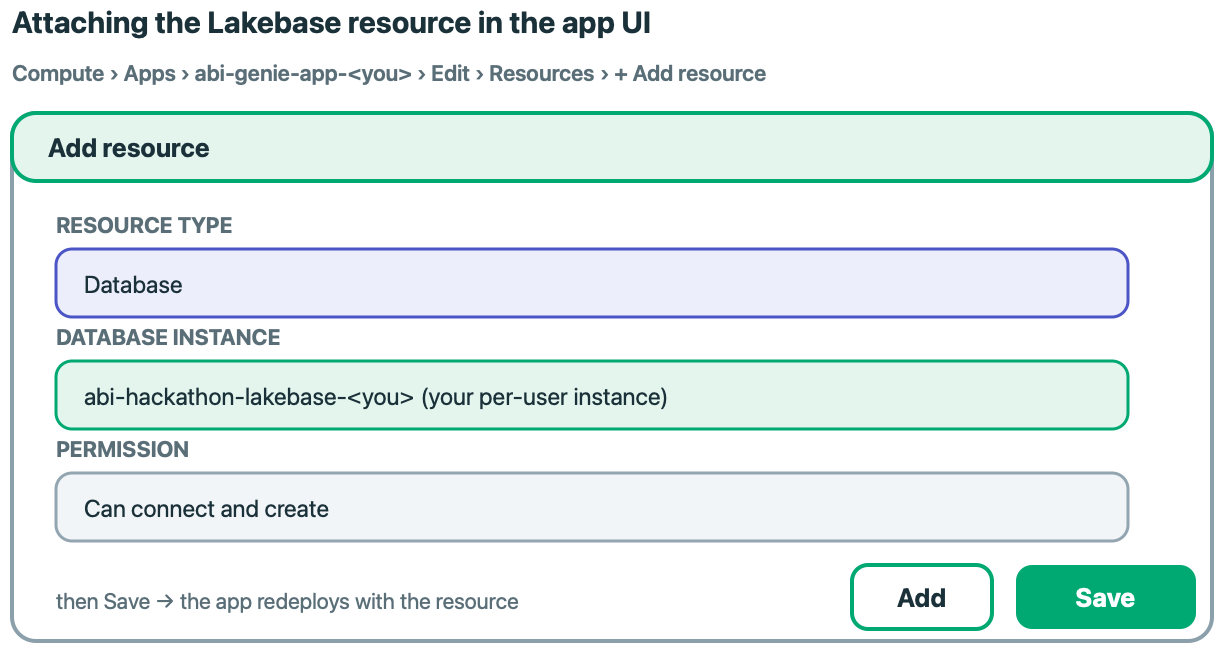

1. **Compute → Apps →** your app (`abi-genie-app-<you>`) **→ Edit → Resources → + Add resource**.
2. **Resource type:** Database. **Instance:** your per-user `abi-hackathon-lakebase-<you>`.
   **Permission:** *Can connect and create*.
3. **Add → Save.** The app redeploys with the resource; the SP now has a Postgres role.
4. Then run **Step 5** below (5b grants the table privileges) and reload the app.

> This is the reliable way to provision the SP's role on workspaces that don't let
> you attach it from code. It's a diagram of the form, not a live screenshot — the
> real screen is under **Compute → Apps → Edit → Resources**.

## Step 5 · Grant the app's service principal data access

The app runs as its **own service principal (SP)**, so grant that SP:
1. **Unity Catalog** — `SELECT` on the 4 curated tables (Genie runs SQL as the SP).
2. **Lakebase Postgres** — `INSERT` on `app.conversations`, full CRUD on
   `app.action_items`, `app.distributors` (Edit tab) and `app.forecast_scenarios`
   (Forecast tab), and `SELECT` on `app.demand_forecast` (the tables are owned by
   *you*, not the SP), plus the SERIAL/BIGSERIAL sequences.
3. **SQL warehouse** — `CAN_USE` on the warehouse the Genie space runs on. Easy to
   miss: the `CAN_RUN` genie resource lets the SP *call* Genie, but Genie executes
   its SQL on a warehouse the SP must be allowed to use, or you get
   *"not authorized to use ... this SQL Endpoint."*
4. **Knowledge Assistant endpoint** — `CAN_QUERY` (also set by the
   `serving_endpoint` resource in Step 4; 5d below makes it explicit).
5. **Demand-forecast endpoint** — `CAN_QUERY` for the Forecast tab's live inference
   (also set by the Step 4 resource; 5e below makes it explicit).

All of these are automated below — the SP id is fetched from the app, no copy-paste.

In [ ]:
# 5a · Unity Catalog grants (run in this notebook; uses spark).
from databricks.sdk import WorkspaceClient
import re
w = WorkspaceClient()

dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (username appended — matches NB1)")
# Same per-user identity as the other notebooks (deterministic).
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
_slug = re.sub(r"[^a-z0-9]+", "_", _user.split("@")[0].lower()).strip("_")[:30]
_dslug = _slug.replace("_", "-")
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{_slug}"
APP_NAME = f"abi-genie-app-{_dslug}"   # per-user app name

app = w.apps.get(name=APP_NAME)
SP = app.service_principal_client_id
print(f"App {APP_NAME} · SP: {SP}  ({app.service_principal_name})")

spark.sql(f"GRANT USE CATALOG ON CATALOG {CATALOG} TO `{SP}`")
spark.sql(f"GRANT USE SCHEMA ON SCHEMA {CATALOG}.{SCHEMA} TO `{SP}`")
for t in ["products", "distributors", "orders", "shipments"]:
    spark.sql(f"GRANT SELECT ON TABLE {CATALOG}.{SCHEMA}.{t} TO `{SP}`")
print(f"Granted SELECT on 4 tables to the app SP.")

In [ ]:
# 5b · Give the app SP access to your Lakebase instance, then grant table privileges.
#
# The deployed app authenticates to Lakebase AS ITS SERVICE PRINCIPAL, so the SP needs
# a Postgres role on the instance. That role is provisioned when the SP has **CAN_USE**
# on the instance — which you can grant directly (you own the instance, Notebook 5).
# This is what makes the app connect ("password authentication failed for user <sp>"
# otherwise), and it works even if the Database *resource* couldn't be attached in
# Step 4 (attaching needs MANAGE; this CAN_USE grant does not).
import time as _t
from databricks.sdk.service.iam import AccessControlRequest, PermissionLevel

try:
    w.permissions.update(
        request_object_type="database-instances", request_object_id=INSTANCE,
        access_control_list=[AccessControlRequest(
            service_principal_name=SP, permission_level=PermissionLevel.CAN_USE)])
    print(f"Granted CAN_USE on Lakebase instance '{INSTANCE}' to the app SP.")
except Exception as e:  # noqa: BLE001
    print(f"(Couldn't grant CAN_USE on '{INSTANCE}': {str(e).splitlines()[0][:110]}) "
          f"— you must own the instance (create it in Notebook 5).")

# The SP's Postgres role (its role name IS its client id) provisions a few seconds
# after the grant — poll for it, then grant table-level privileges.
_role_ok = False
for _ in range(24):   # ~2 min (role provisioning is async)
    with engine.connect() as c:
        if c.execute(text("SELECT 1 FROM pg_roles WHERE rolname = :r"), {"r": SP}).first():
            _role_ok = True
            break
    _t.sleep(5)

if not _role_ok:
    print(f"⚠️  SP role '{SP}' not provisioned on '{INSTANCE}' yet.")
    print("    Provisioning is async — **just re-run this cell** (give it a minute or two).")
    print("    If it still won't appear after a few tries, the instance's identity→role sync")
    print("    isn't picking up the CAN_USE grant on this workspace: ask an admin to grant you")
    print("    CAN_MANAGE on the instance and re-run Step 4 (attaching the Database resource")
    print("    provisions the role directly). Skipping the table grants for now.")
else:
    with engine.begin() as c:
        c.execute(text(f'GRANT USAGE ON SCHEMA app TO "{SP}"'))
        c.execute(text(f'GRANT SELECT, INSERT ON app.conversations TO "{SP}"'))
        # action_items is read/written by the app's "Action items" tab — full CRUD.
        c.execute(text(f'GRANT SELECT, INSERT, UPDATE, DELETE ON app.action_items TO "{SP}"'))
        # distributors is edited in place by the "Edit distributors" tab — full CRUD.
        c.execute(text(f'GRANT SELECT, INSERT, UPDATE, DELETE ON app.distributors TO "{SP}"'))
        # forecast_scenarios stores each what-if inference from the Forecast tab.
        c.execute(text(f'GRANT SELECT, INSERT, UPDATE, DELETE ON app.forecast_scenarios TO "{SP}"'))
        # products and demand_forecast are read-only reference/output the app only SELECTs.
        c.execute(text(f'GRANT SELECT ON app.products TO "{SP}"'))
        c.execute(text(f'GRANT SELECT ON app.demand_forecast TO "{SP}"'))
        # serial/bigserial sequences backing the write-back tables.
        c.execute(text(f'GRANT USAGE, SELECT ON ALL SEQUENCES IN SCHEMA app TO "{SP}"'))
    print(f"Granted read/write access on the app tables to the app SP.")

In [ ]:
# 5c · SQL-warehouse grant — the SP must be allowed to USE the warehouse the
# Genie space runs its SQL on (otherwise: "not authorized to use this SQL Endpoint").
from databricks.sdk.service import sql as sqlsvc

dbutils.widgets.text("genie_space_id", "", "Genie space id (from Notebook 2)")
GENIE_SPACE_ID = dbutils.widgets.get("genie_space_id").strip()
assert GENIE_SPACE_ID, "Set the genie_space_id widget (from Notebook 2's output)."

wh_id = w.genie.get_space(GENIE_SPACE_ID).warehouse_id
try:
    w.warehouses.update_permissions(  # additive — keeps existing ACLs
        warehouse_id=wh_id,
        access_control_list=[sqlsvc.WarehouseAccessControlRequest(
            service_principal_name=SP,
            permission_level=sqlsvc.WarehousePermissionLevel.CAN_USE)],
    )
    print(f"Granted CAN_USE on warehouse {wh_id} to the app SP.")
except Exception as e:  # noqa: BLE001 — you need MANAGE on the warehouse to grant it
    print(f"⚠️  Couldn't grant the SP CAN_USE on warehouse {wh_id}: {str(e).splitlines()[0][:110]}")
    print("    Granting warehouse permissions needs MANAGE on it — which you won't have on a")
    print("    shared/admin-owned warehouse. Ask its owner (or an admin) to grant the app SP")
    print(f"    '{SP}' (or all users) CAN_USE on warehouse {wh_id}. Without it, the Ask-Genie tab")
    print("    fails at runtime with 'not authorized to use ... this SQL Endpoint'. (Everything")
    print("    else — the app, forecast, Lakebase tabs — is unaffected.)")

In [ ]:
# 5d · Knowledge Assistant grant — the SP must be able to query the assistant's
# serving endpoint (the "Ask the docs" tab). Redundant if the Step 4
# serving_endpoint resource applied, but explicit and safe to re-run.
from databricks.sdk.service.serving import (
    ServingEndpointAccessControlRequest, ServingEndpointPermissionLevel)

dbutils.widgets.text("ka_endpoint", "", "Knowledge Assistant endpoint (from Notebook 3)")
KA_ENDPOINT = dbutils.widgets.get("ka_endpoint").strip()
if not KA_ENDPOINT:
    print("Skipped — set the ka_endpoint widget to grant CAN_QUERY on the assistant.")
else:
    try:
        ep = w.serving_endpoints.get(name=KA_ENDPOINT)   # errors if the name is wrong
        w.serving_endpoints.update_permissions(  # additive — keeps existing ACLs
            serving_endpoint_id=ep.id,
            access_control_list=[ServingEndpointAccessControlRequest(
                service_principal_name=SP,
                permission_level=ServingEndpointPermissionLevel.CAN_QUERY)],
        )
        print(f"Granted CAN_QUERY on '{KA_ENDPOINT}' to the app SP.")
    except Exception as e:  # noqa: BLE001 — wrong name / not deployed yet
        print(f"(Couldn't grant on KA endpoint '{KA_ENDPOINT}': {str(e).splitlines()[0][:100]}) "
              f"— check the ka_endpoint widget is the endpoint NAME from Notebook 3.")

In [ ]:
# 5e · Demand-forecast endpoint grant — the SP must query the forecast endpoint for
# the Forecast tab's live what-if inference. Redundant if the Step 4 serving_endpoint
# resource applied, but explicit and safe to re-run. (Moved here from Notebook 4:
# it can only succeed once the app — and therefore its SP — exists.)
from databricks.sdk.service.serving import (
    ServingEndpointAccessControlRequest, ServingEndpointPermissionLevel)
try:
    ep = w.serving_endpoints.get(name=FORECAST_ENDPOINT)
    w.serving_endpoints.update_permissions(  # additive — keeps existing ACLs
        serving_endpoint_id=ep.id,
        access_control_list=[ServingEndpointAccessControlRequest(
            service_principal_name=SP,
            permission_level=ServingEndpointPermissionLevel.CAN_QUERY)],
    )
    print(f"Granted CAN_QUERY on '{FORECAST_ENDPOINT}' to the app SP.")
except Exception as e:  # noqa: BLE001 — e.g. the endpoint is still provisioning
    print(f"(Couldn't grant on '{FORECAST_ENDPOINT}': {str(e)[:90]})")

## Step 6 · Use it, then inspect what was logged

Open the app URL and try all four tabs — **Ask Genie** (data), **Ask the docs**
(Knowledge Assistant), **Forecast** (the chart from Lakebase), and **Action items**
(the review queue). Then run this cell to see the conversations the app wrote to
Lakebase — proof the whole loop works end to end.

In [ ]:
import pandas as pd
with engine.connect() as c:
    df = pd.read_sql(
        "SELECT created_at, user_email, question, result_row_count, "
        "left(generated_sql, 80) AS sql_preview "
        "FROM app.conversations ORDER BY created_at DESC LIMIT 20",
        c,
    )
print(f"{len(df)} logged conversation turns")
display(df) if 'display' in dir() else print(df.to_string(index=False))

## Step 7 · Auto-shutdown (cost control) 💸

Apps and Lakebase **bill while running** and have no built-in TTL. So schedule a
**one-shot job** that stops both after a few hours. It runs the sibling
`_stop_resources` notebook via a **Quartz cron pinned to a single future minute**
(so it fires exactly once). Adjust `shutdown_after_hours`.

Need it sooner, or want to keep going? Stop now, or delete the job (use *your*
per-user app name, e.g. `abi-genie-app-jsmith`):
```bash
databricks apps stop abi-genie-app-<your-username> -p <profile>
# The Lakebase instance is SHARED — only stop it if no one else is using it:
databricks database update-database-instance abi-hackathon-lakebase "stopped" --stopped -p <profile>
# databricks jobs delete <job_id>   # cancel the scheduled auto-shutdown
```

In [ ]:
import datetime as dt, os
from databricks.sdk import WorkspaceClient
from databricks.sdk.service import jobs
w = WorkspaceClient()

import re
dbutils.widgets.text("app_name", "", "Databricks App name (blank = auto per-user)")
dbutils.widgets.text("lakebase_instance", "abi-hackathon-lakebase", "Lakebase instance base (username appended)")
dbutils.widgets.text("shutdown_after_hours", "3", "Auto-shutdown after N hours")
_user = spark.sql("SELECT current_user()").collect()[0][0]
_dslug = re.sub(r"[^a-z0-9]+", "-", _user.split("@")[0].lower()).strip("-")[:30]
APP = dbutils.widgets.get("app_name").strip() or f"abi-genie-app-{_dslug}"
INSTANCE = f"{dbutils.widgets.get('lakebase_instance').strip()}-{_dslug}"   # per-user instance (matches NB5)
N = float(dbutils.widgets.get("shutdown_after_hours"))
print(f"Auto-shutdown target app: {APP}")

# Locate the sibling _stop_resources notebook (same folder as this one).
nb_path = (dbutils.notebook.entry_point.getDbutils().notebook()
           .getContext().notebookPath().get())
stop_nb = os.path.dirname(nb_path) + "/_stop_resources"

# Quartz cron pinned to one future minute (UTC) => fires once.
target = dt.datetime.utcnow() + dt.timedelta(hours=N)
cron = f"0 {target.minute} {target.hour} {target.day} {target.month} ? {target.year}"
print(f"Auto-shutdown ~{target:%Y-%m-%d %H:%M} UTC  (cron: {cron})")

# Per-user job name so several participants don't collide.
me = w.current_user.me().user_name.split("@")[0].replace(".", "_")
JOB_NAME = f"abi-autoshutdown-{me}"

# Recreate if it already exists.
for j in w.jobs.list():
    if j.settings and j.settings.name == JOB_NAME:
        w.jobs.delete(job_id=j.job_id)

created = w.jobs.create(
    name=JOB_NAME,
    tasks=[jobs.Task(
        task_key="stop",
        notebook_task=jobs.NotebookTask(
            notebook_path=stop_nb,
            base_parameters={"app_name": APP, "lakebase_instance": INSTANCE},
        ),
    )],
    schedule=jobs.CronSchedule(quartz_cron_expression=cron, timezone_id="UTC"),
)
print(f"✔ Scheduled auto-shutdown job '{JOB_NAME}' (id {created.job_id}).")
print(f"  Cancel with:  databricks jobs delete {created.job_id}")

## ✅ Recap — and how this maps to the hackathon

You shipped a governed, full-stack pattern end to end:

- **Notebook 1** → curated Delta tables + a docs **Volume** (one governed copy)
- **Notebook 2** → a **Genie agent** made accurate by metadata (comments,
  constraints, example SQL)
- **Notebook 3** → an **Agent Bricks Knowledge Assistant** over the docs (cited answers)
- **Notebook 4** → a **demand forecast** (MLflow) written to Delta
- **Notebook 5** → **Lakebase** for transactional app state (and the forecast copy)
- **Notebook 6** → this **Databricks App** wiring **Genie + Knowledge Assistant +
  forecast + Lakebase** into one UI, running as a service principal
- **Genie Code** (optional, unnumbered) → governed, AI-assisted development off Notebooks 1–2

**This is a reusable MVP pattern.** Several hackathon tracks are variations on it:
- *EPR Reporting* → Genie over curated reporting tables
- *Policy / SOP Q&A* → a Knowledge Assistant over a docs Volume
- *Demand / Freight forecasting* → an MLflow model surfaced in the app
- *Lease / Contract Management, review queues* → Lakebase-backed app state + approvals
- *DPM / Sigma replacement* → a Databricks App as the product surface

Swap the dataset, the Genie space, the docs, and the model — keep the skeleton.
**That completes the enablement series. You're ready to build.** 🍺

> 🧹 **When you're completely done**, run **`_cleanup`** (the sibling utility notebook)
> to tear down everything you created — the app, serving endpoints, Genie space,
> Lakebase logical DB, and the UC schema — so nothing is left billing.